In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
import json
warnings.filterwarnings('ignore')

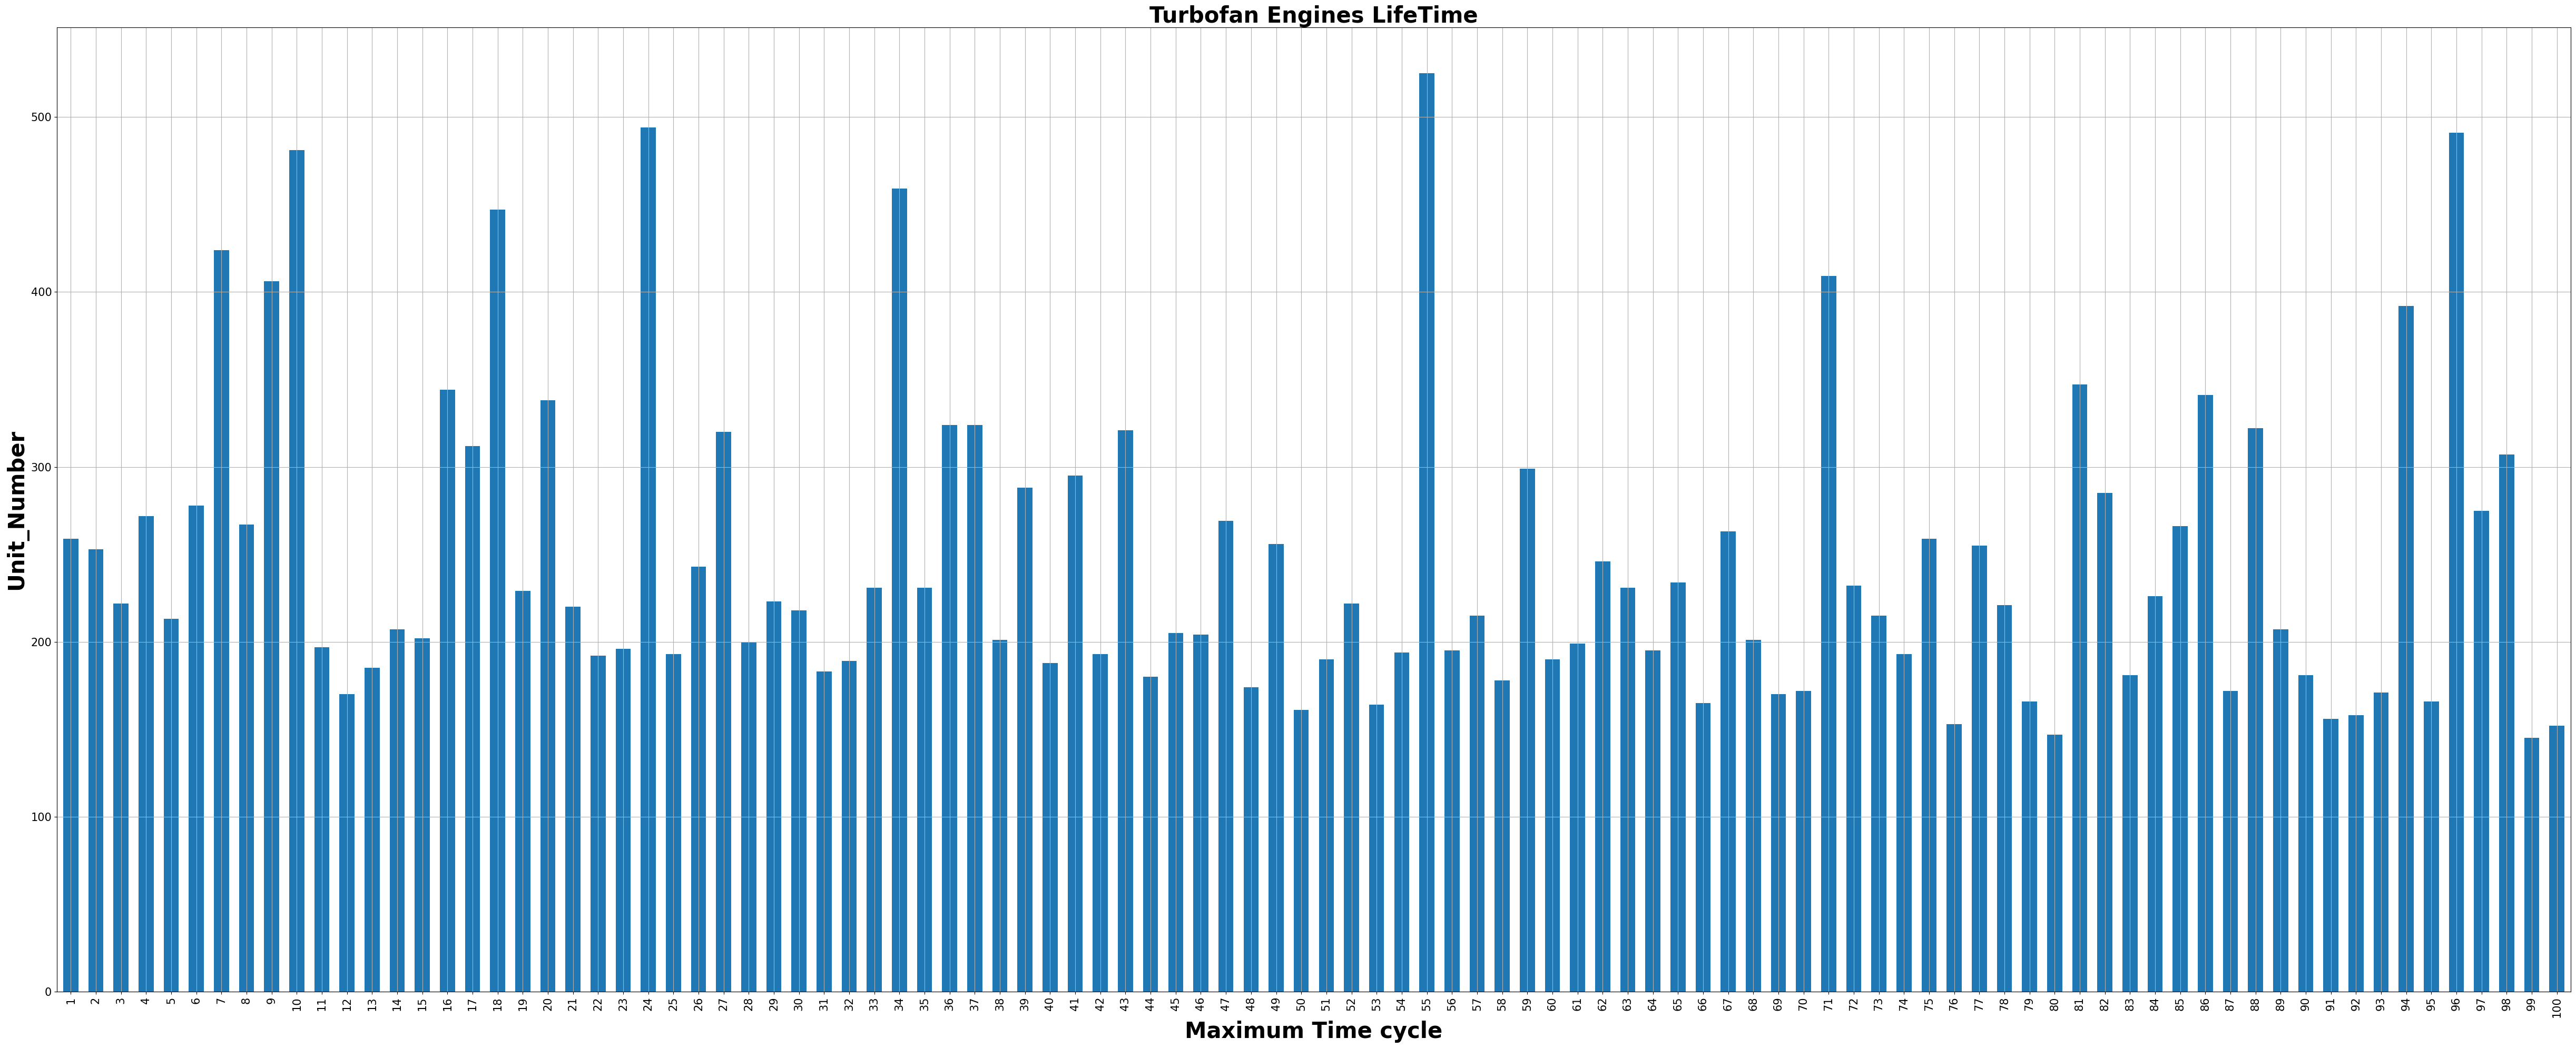

In [2]:
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i+1) for i in range(0,21)]
col_names = index_names + setting_names + sensor_names
filenum = 3
CurrentFile = f"train_FD00{filenum}"
df = pd.read_csv('CMaps/'+ CurrentFile + '.txt',sep='\s+',header=None,index_col=False,names=col_names)
# df.iloc[-1]
# df.head()
max_time_cycles=df[index_names].groupby('unit_number').max()
max_time_cycles.head()
plt.figure(figsize=(49,20))
ax=max_time_cycles['time_cycles'].plot(kind='bar',width=0.6, stacked=True,align='center')
plt.title('Turbofan Engines LifeTime',fontweight='bold',size=30)
plt.xlabel('Maximum Time cycle',fontweight='bold',size=30)
plt.xticks(size=15)
plt.ylabel('Unit_Number',fontweight='bold',size=30)
plt.yticks(size=15)
plt.grid(True)
plt.tight_layout()
plt.savefig('Turbofan_Engines_LifeTime.png')
plt.show()


In [3]:
def VecNorm(UnNormArr):
    #Column wise normalization of each time series sample
    NormArr = UnNormArr
    for i in range(len(UnNormArr)):
        for j in range(len(UnNormArr[i][0])):
            # print([UnNormArr[i][k][j] for k in range(len(UnNormArr[i]))], "\n")
            NormFac = sum([UnNormArr[i][k][j] ** 2 for k in range(len(UnNormArr[i]))])**0.5
            # print(NormFac)
            NormCol = [UnNormArr[i][k][j]/NormFac for k in range(len(UnNormArr[i]))]
            # print(NormCol)
            # print(i,j,len(NormCol), len(NormArr[i]))
            # NormArr[i][:][j] = NormCol

            for k in range(len(UnNormArr[i])):
                NormArr[i][k][j] = NormCol[k]
            # print(NormArr[i][:][j])
            # print([NormArr[i][k][j] for k in range(len(NormArr[i]))], "\n")
            # print(f"Done W row {i} col {j}")
    return NormArr

def normalize_dataframe(df, columns_to_normalize):
    """
    Normalize specified columns of a DataFrame column-wise.

    Parameters:
    df (pd.DataFrame): The DataFrame to normalize.
    columns_to_normalize (list): List of column names to normalize.

    Returns:
    pd.DataFrame: A DataFrame with normalized columns.
    """
    drop = []
    mins = []
    maxes = []
    for column in columns_to_normalize:
        mins.append(df[column].min())
        maxes.append(df[column].max())
        
        print(f"{column} min: {df[column].min()}, max: {df[column].max()}")
        if df[column].min() == df[column].max():
            drop.append(column)
        df[column] = (df[column] - df[column].min()) / (df[column].max() - df[column].min())  # add small epsilon to prevent division by zero
        
    df = df.drop(columns=drop)
    print(f"Dropped: {len(drop)} columns \n {drop}")
    print(f"\n Mins = {mins}")
    print(f"\n Maxes = {maxes}")

    return df
import numpy as np

def all_up(data, n_start=5, n_end=10):
    result = []
    
    for unit in data:
        if len(unit) == 0:
            result.append([])
            continue
            
        # Convert to numpy for easier manipulation
        unit_array = np.array(unit)
        seq_len, n_features = unit_array.shape
        unit_result = unit_array.copy()
        
        for f in range(n_features):
            # Calculate start and end averages
            n_start_actual = min(n_start, seq_len)
            n_end_actual = min(n_end, seq_len)
            
            start_avg = np.mean(unit_array[:n_start_actual, f])
            end_avg = np.mean(unit_array[-n_end_actual:, f])
            
            # If signal is decreasing (end < start), flip it around its start value
            if end_avg < start_avg:
                # Mirror formula: 2*start - x
                unit_result[:, f] = 2 * start_avg - unit_array[:, f]
        
        # Convert back to list
        result.append(unit_result.tolist())
    
    return result

In [4]:
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i+1) for i in range(0,21)]
col_names = index_names + setting_names + sensor_names
for filenum in range(1,2):
    print(f"{filenum}\n\n")
    CurrentFile = f"train_FD00{filenum}"
    df = pd.read_csv('CMaps/'+ CurrentFile + '.txt',sep='\s+',header=None,index_col=False,names=col_names)
    df.drop(columns=['setting_1', 'setting_2', 'setting_3'], inplace=True)
    # print(df.iloc[0,:])
    # df = normalize_dataframe(df, sensor_names)
    # print(df.iloc[0,:])
    # break
    Data = [[] for _ in range(df.iloc[-1,0])]
    for i in range(len(df)):
        row = df.iloc[i,2:]
        idx = int(df.iloc[i,0] - 1)
        Data[idx].append(row.tolist())

    dmodel = 24
    # data_pos = Data
    # Data
    # data_pos = Data
    # print(len(data_pos), len(data_pos[0]),len(data_pos[0][0]))
    # for i in range(len(Data)):
    #     posenc1 = positional_encoding(i,dmodel)
    #     posenc1 = posenc1.tolist()
    #     for j in range(len(Data[i])):
    #         posenc2 = positional_encoding(j,dmodel)
    #         posenc2 = posenc2.tolist()
    #         for k in range(len(posenc1)):
    #             data_pos[i][j][k] += posenc1[k] + posenc2[k]
    # Data_allup, flipped = all_up(Data)
    Data_allup = all_up(Data)


1




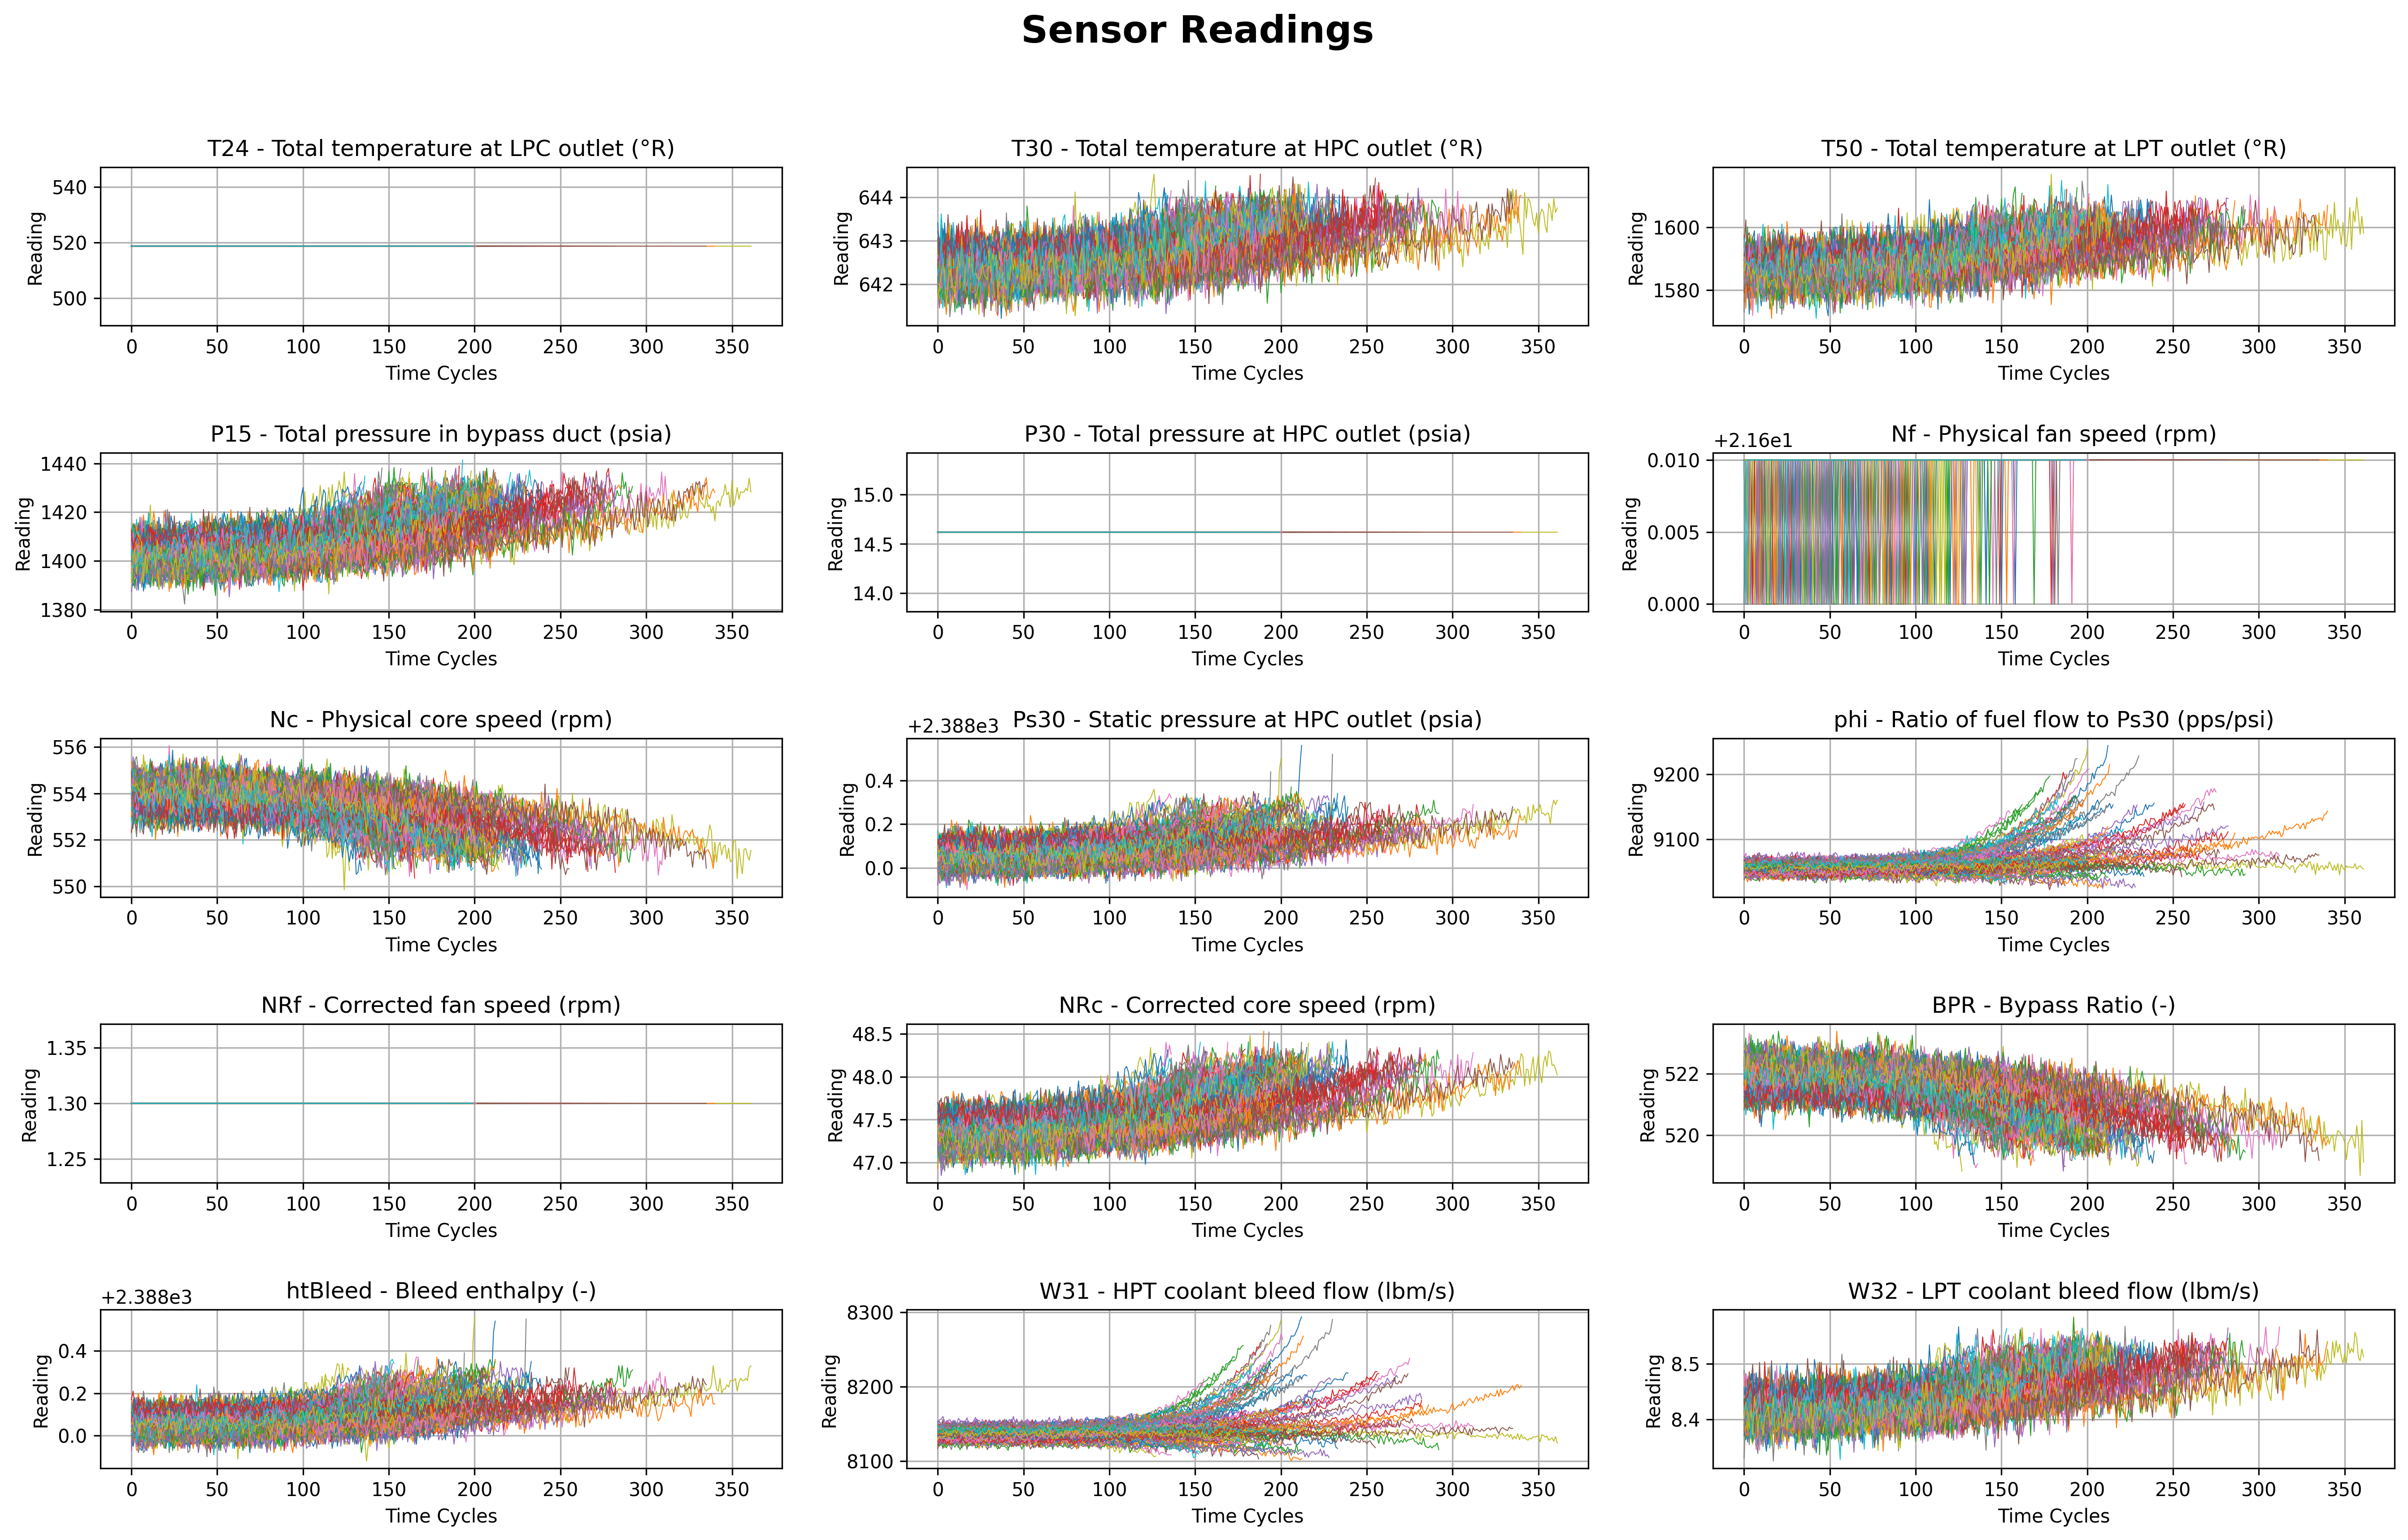

In [5]:
# Data_allup, flipped = all_up(Data)
fig, axs = plt.subplots(5, 3, figsize=(18, 12), dpi=300)
fig.suptitle('Sensor Readings ', fontsize=20, fontweight='bold')
# fig.suptitle(f'(for non constant sensors)', fontsize=16)
sensor_labels = [
    "T24 - Total temperature at LPC outlet (°R)",
    "T30 - Total temperature at HPC outlet (°R)",
    "T50 - Total temperature at LPT outlet (°R)",
    "P15 - Total pressure in bypass duct (psia)",
    "P30 - Total pressure at HPC outlet (psia)",
    "Nf - Physical fan speed (rpm)",
    "Nc - Physical core speed (rpm)",
    "Ps30 - Static pressure at HPC outlet (psia)",
    "phi - Ratio of fuel flow to Ps30 (pps/psi)",
    "NRf - Corrected fan speed (rpm)",
    "NRc - Corrected core speed (rpm)",
    "BPR - Bypass Ratio (-)",
    "htBleed - Bleed enthalpy (-)",
    "W31 - HPT coolant bleed flow (lbm/s)",
    "W32 - LPT coolant bleed flow (lbm/s)"
]

n_sensors_to_plot = len(sensor_labels)


for idx in range(n_sensors_to_plot):
    ax = axs[idx // 3, idx % 3]
    for engine in Data:
        signal = [flight[idx] for flight in engine]
        ax.plot(signal, linewidth=0.5)
    ax.set_title(f'{sensor_labels[idx]}')
    ax.set_xlabel('Time Cycles')
    ax.set_ylabel('Reading')
    ax.grid(True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('Sensor_Readings.png')
plt.show()

Columns in CSV: ['timestamp', 'epoch', 'batch', 'train_loss', 'pinns_loss', 'train_acc', 'test_loss', 'test_pinns_loss', 'test_acc', 'learning_rate', 'elapsed_seconds', 'gpu_memory_allocated_gb']
Sample data:
             timestamp  epoch batch  train_loss  pinns_loss  train_acc  \
0  2025-09-13 15:17:59      0     0    0.318629   37.381409   0.005938   
1  2025-09-13 15:17:59      0     1    0.370636   36.740643   0.009440   
2  2025-09-13 15:18:00      0     2    0.355220   38.067532   0.009265   
3  2025-09-13 15:18:00      0     3    0.347557   37.936317   0.010086   
4  2025-09-13 15:18:00      0     4    0.305536   37.184441   0.007539   

   test_loss  test_pinns_loss  test_acc  learning_rate  elapsed_seconds  \
0        NaN              NaN       NaN        0.00002         1.699443   
1        NaN              NaN       NaN        0.00002         2.136317   
2        NaN              NaN       NaN        0.00002         2.570209   
3        NaN              NaN       NaN       

KeyError: 'epoch'